In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import tensorflow_probability.substrates.jax.distributions as distributions

from flax import nnx
from tqdm import tqdm

from confrdm_jax.simulators import sample_conditional_wald, create_wald_prior_uniform
from confrdm_jax.flows import make_mlp_conditioner, spline_flow

In [3]:
prior = create_wald_prior_uniform()

samples = prior.sample(seed=1234, sample_shape=(10, 3))

In [4]:
jnp.where(jnp.array(samples) < 0.0)

(Array([], shape=(0,), dtype=int32),
 Array([], shape=(0,), dtype=int32),
 Array([], shape=(0,), dtype=int32))

In [5]:
key = jax.random.key(seed=1234)

data, context = sample_conditional_wald(key, (10, 5), prior)

In [6]:
data.shape, context.shape

((10, 5), (10, 1, 3))

In [7]:
rngs = nnx.Rngs(0)

conditioner = make_mlp_conditioner(num_bins=8, rngs=rngs)
x = conditioner(context)
x.shape

(10, 1, 25)

In [8]:
log_probs, _ = spline_flow(data.squeeze(), context, conditioner)
jnp.where(jnp.isnan(log_probs))

(Array([], shape=(0,), dtype=int32), Array([], shape=(0,), dtype=int32))

In [80]:
def loss_fn(conditioner, data, context):
  # context = jnp.exp(context)
  log_probs, _ = spline_flow(data.squeeze(), context, conditioner)
  return -jnp.mean(jnp.where(jnp.isfinite(log_probs), log_probs, jnp.log(1e-12)))

@nnx.jit
def train_step(conditioner, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, data, context):
  grad_fn = nnx.value_and_grad(loss_fn)
  loss, grads = grad_fn(conditioner, data, context)
  metrics.update(loss=loss)  # In-place updates.
  optimizer.update(conditioner, grads)  # In-place updates.

@nnx.jit
def eval_step(conditioner, metrics: nnx.MultiMetric, data, context):
  loss = loss_fn(conditioner, data, context)
  metrics.update(loss=loss)  # In-place updates.

def evaluate_pdf_sf(conditioner, data, context):
    conditioner.eval()

    _, flow = spline_flow(data.squeeze(), context, conditioner)

    z = flow.bijector.inverse(data)
    
    return flow.log_prob(data), jax.scipy.stats.norm.logsf(z)

def ref_log_pdf_sf(data, v, s, b):
    # mu_winner = b/drift_winner
    mu = b / v
    # lam_winner = (b/s_winner)**2
    lam = (b / s)**2

    dist = distributions.InverseGaussian(mu, lam)

    return dist.log_prob(data), dist.log_survival_function(data)

In [81]:
loss_fn(conditioner, data, context)

Array(1.3272635, dtype=float32)

In [ ]:
train_steps = 50_000

eval_every = int(train_steps // 10)

batch_shape = (64, 200)

metrics_history = {
  "train_loss": [],
  "train_kl_pdf": [],
  "train_kl_sf": [],
}

master_key = jax.random.key(2027)
train_key, test_key = jax.random.split(master_key)
conditioner_key, sampling_key = jax.random.split(train_key, 2)

rngs = nnx.Rngs(default=conditioner_key, sampling=sampling_key)

conditioner = make_mlp_conditioner(num_bins=4, rngs=rngs)

learning_rate = 0.005 # optax.schedules.cosine_decay_schedule(0.005, train_steps, 1e-6)

optimizer = nnx.Optimizer(
  conditioner, optax.adamw(learning_rate), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  loss=nnx.metrics.Average('loss'),
)

for step in tqdm(range(train_steps)):
  data, context = sample_conditional_wald(rngs.sampling(), batch_shape, prior)
  # Run the optimization for one step and make a stateful update to the following:
  # - The train state's model parameters
  # - The optimizer state
  # - The training loss and accuracy batch metrics
  conditioner.train() # Switch to train mode
  train_step(conditioner, optimizer, metrics, data, context)

  if step > 0 and (step % eval_every == 0 or step == train_steps - 1):  # One training epoch has passed.
    # Log the training metrics.
    for metric, value in metrics.compute().items():  # Compute the metrics.
      metrics_history[f'train_{metric}'].append(value)  # Record the metrics.
    metrics.reset()  # Reset the metrics for the test set.

    conditioner.eval()

    test_data, test_context = sample_conditional_wald(rngs.sampling(), batch_shape, prior)
    # test_data = test_data.squeeze()
    # test_context = test_context.squeeze()
    ref_pdf, ref_sf = ref_log_pdf_sf(test_data, test_context[..., 0], test_context[..., 1], test_context[..., 2])

    test_pdf, test_sf = evaluate_pdf_sf(conditioner, test_data, test_context)

    kl_pdf = jnp.nanmean(jax.scipy.special.kl_div(jnp.exp(ref_pdf), jnp.exp(test_pdf)))
    kl_sf = jnp.nanmean(jax.scipy.special.kl_div(jnp.exp(ref_sf), jnp.exp(test_sf)))

    metrics_history["train_kl_pdf"].append(kl_pdf)
    metrics_history["train_kl_sf"].append(kl_sf)

    print(value, kl_pdf, kl_sf)
   

  9%|▉         | 4681/50000 [00:14<02:18, 326.60it/s]


KeyboardInterrupt: 

In [153]:
metrics_history

{'train_loss': [Array(0.98798347, dtype=float32),
  Array(0.9230878, dtype=float32),
  Array(0.9014279, dtype=float32),
  Array(0.8972537, dtype=float32),
  Array(0.91952324, dtype=float32),
  Array(0.8858886, dtype=float32),
  Array(0.8887522, dtype=float32),
  Array(0.8939374, dtype=float32),
  Array(0.8989562, dtype=float32),
  Array(0.9002955, dtype=float32)],
 'train_kl_pdf': [Array(2430.0957, dtype=float32),
  Array(569.1274, dtype=float32),
  Array(3481.6887, dtype=float32),
  Array(4880.818, dtype=float32),
  Array(208.0145, dtype=float32),
  Array(inf, dtype=float32),
  Array(143.98187, dtype=float32),
  Array(297.98636, dtype=float32),
  Array(inf, dtype=float32),
  Array(125.32893, dtype=float32)],
 'train_kl_sf': [Array(0.02520575, dtype=float32),
  Array(0.02449136, dtype=float32),
  Array(0.03893816, dtype=float32),
  Array(0.04273833, dtype=float32),
  Array(0.03617033, dtype=float32),
  Array(0.02950922, dtype=float32),
  Array(0.04845154, dtype=float32),
  Array(0.0502

In [159]:
test_data, test_context = sample_conditional_wald(test_key, (100,), prior)
# test_data = test_data.squeeze()
# test_context = test_context.squeeze()

In [160]:
test_data.shape, test_context.shape

((100,), (1, 3))

In [161]:
test_pdf, test_sf = evaluate_pdf_sf(conditioner, test_data, test_context)
test_pdf.shape, test_sf.shape

((100,), (100,))

In [162]:
ref_pdf, ref_sf = ref_log_pdf_sf(test_data, test_context[..., 0], test_context[..., 1], test_context[..., 2])
ref_pdf.shape, ref_sf.shape

((100,), (100,))

In [163]:
jax.scipy.special.kl_div(jnp.exp(ref_pdf), jnp.exp(test_pdf)).mean()
# jax.scipy.special.kl_div(jnp.exp(ref_sf), jnp.exp(test_sf)).mean()

Array(0.00274255, dtype=float32)

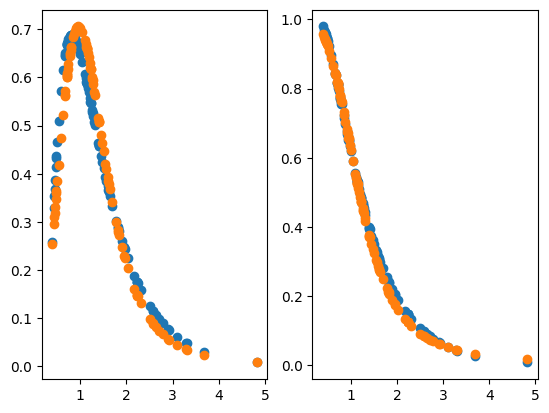

In [164]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(test_data, jnp.exp(ref_pdf), "o", label="Reference")
ax1.plot(test_data, jnp.exp(test_pdf), "o", label="Approx")

ax2.plot(test_data, jnp.exp(ref_sf), "o", label="Reference")
ax2.plot(test_data, jnp.exp(test_sf), "o", label="Approx")

In [196]:
@jax.jit
def inv_gauss_log_pdf_sf(rt, v, b, s, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    return evaluate_pdf_sf(conditioner, rt, jnp.array([v, s, b]))

def create_rdm_two_accumulators_likelihood(data):
    rt = data[:, 0]
    choice = data[:, 1]

    @jax.jit
    def likelihood_fun(x, min_ll=1e-12):
        x = jnp.exp(x)

        v_true = x[0] + x[1]
        v_false = x[0]
        s_true = x[2]
        s_false = 1.0
        b = x[3]
        t0 = x[4]

        log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(rt, v_true, b, s_true, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_false, b, s_false, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(min_ll))

    return likelihood_fun

import numpy as np
from confrdm.simulators.rdm import simulate_rdm_two_accumulators

test_params = dict(
    v_intercept=1.0,
    v_slope=3.0,
    s_true=1.5,
    b=1.1,
    t0=0.2,
)

test_data = simulate_rdm_two_accumulators(
    **test_params,
    num_obs=500,
    rng=np.random.default_rng(2027)
)["x"]

rdm_likelihood = create_rdm_two_accumulators_likelihood(test_data)

In [197]:
from jax.scipy import stats

@jax.jit
def rdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)
    
    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    s_true = scale_logtruncnorm(x[2], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[3], a=12.0, scale=0.15)
    t0 = scale_logtruncnorm(x[4], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + s_true + b + t0

In [198]:
import blackjax

def inference_loop_multiple_chains(
    rng_key, kernel, initial_state, num_samples, num_chains
):
    @jax.jit
    def one_step(states, rng_key):
        keys = jax.random.split(rng_key, num_chains)
        states, _ = jax.vmap(kernel)(keys, states)
        return states, states

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states


def warmup(sampler_fun, logdensity_fun, init_position, num_steps, rng_key, **kwargs):
    adapt = blackjax.window_adaptation(sampler_fun, logdensity_fun, **kwargs)
    (last_state, parameters), _ = adapt.run(rng_key, init_position, num_steps=num_steps)
    kernel = sampler_fun(logdensity_fun, **parameters).step
    return kernel, last_state, parameters

In [210]:
@jax.jit
def logdensity_fun(x):
    return rdm_prior(x) + jnp.sum(rdm_likelihood(x))

In [211]:
init_position = jnp.array([1.0, 4.0, 1.0, 0.8, 0.2])
logdensity_fun(jnp.log(init_position))

Array(12.776442, dtype=float32)

In [213]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    500,
    warmup_key,
    progress_bar=True
)

Running window adaptation


In [214]:
jnp.exp(last_state.position)

Array([1.1896842 , 2.8941474 , 1.3422694 , 1.1010127 , 0.18827963],      dtype=float32)

In [215]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 500, num_chains
)

samples = np.moveaxis(np.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))

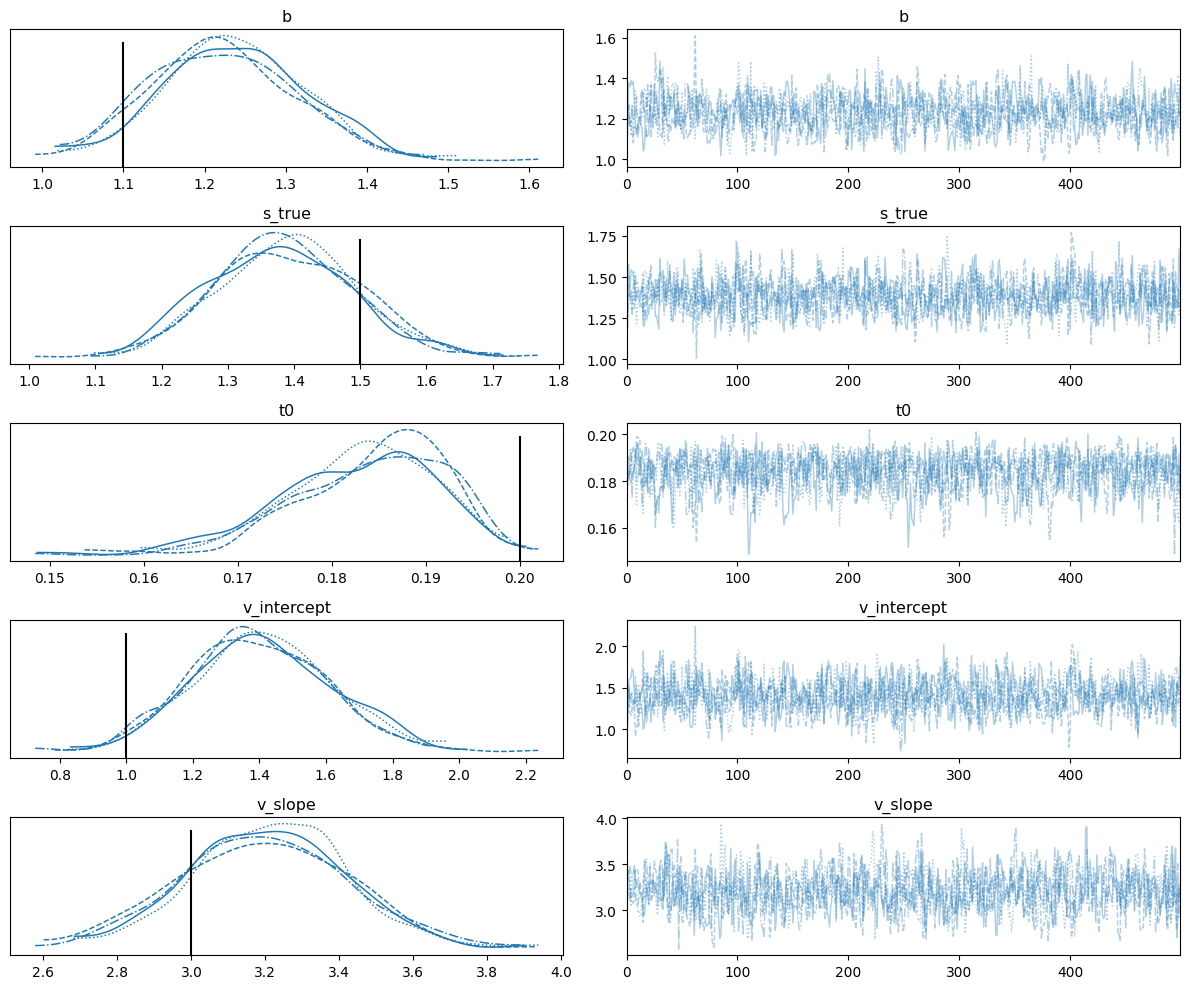

In [216]:
import matplotlib.pyplot as plt
import arviz as az

param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

for i, p in enumerate(sorted(param_names)):
    ax[i, 0].axvline(test_params[p], 0, 0.9, color="k")

plt.tight_layout()